## Setup

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
from src import feature_engineering as fe

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)


## Load dataset

In [2]:
df = fe.load_raw('../data/5g_kpi_dataset.csv')
df.shape


(5000, 13)

## Build feature matrix

In [3]:
X, meta = fe.build_feature_matrix(df.copy())
X.shape, meta.shape


((4760, 10), (4760, 5))

In [4]:
X.head()


,throughput_mbps_zscore,latency_ms_zscore,packet_loss_pct_zscore,handover_count_zscore,rsrp_dbm_zscore,rsrq_db_zscore,prb_utilization_pct_zscore,active_users_zscore,hour_of_day,day_of_week
0,-1.073789,-1.037920,-0.662472,-0.725866,-24.172234,1.514960,0.202315,-0.218218,18,0
1,0.568962,2.248526,-0.781868,-0.957427,-0.896134,0.478815,-0.057005,-0.596040,21,0
2,-1.253701,3.288984,1.169827,-0.072075,-0.284110,-1.193436,0.195064,1.227881,23,0
3,-1.046199,-0.692919,0.004123,0.335578,0.683572,-0.106822,-2.129184,0.570266,2,1
4,-6.236507,-0.766327,-0.724325,-0.124838,0.756858,-0.640266,1.213291,0.977107,3,1


In [5]:
meta.head()


,timestamp,cell_id,slice_type,cell_type,sla_compliant
0,2024-01-01 18:10:00,CELL_001,HC,macro,1
1,2024-01-01 21:37:00,CELL_001,HC,macro,1
2,2024-01-01 23:09:00,CELL_001,HC,macro,0
3,2024-01-02 02:01:00,CELL_001,HC,macro,1
4,2024-01-02 03:09:00,CELL_001,HC,macro,1


## Temporal split

In [6]:
X_train, X_test, meta_train, meta_test = fe.temporal_train_test_split(X, meta)
(X_train.shape, meta_train['timestamp'].min(), meta_train['timestamp'].max()), \
(X_test.shape, meta_test['timestamp'].min(), meta_test['timestamp'].max())


(((3766, 10),
  Timestamp('2024-01-01 00:32:00'),
  Timestamp('2024-01-03 18:45:00')),
 ((994, 10),
  Timestamp('2024-01-03 18:46:00'),
  Timestamp('2024-01-04 11:19:00')))

## Worked example: backward-only window

In [7]:
example_cell, example_slice = 'CELL_015', 'eMBB'
featured = fe.add_rolling_zscore_features(df.copy())
sub = featured[(featured['cell_id'] == example_cell) & (featured['slice_type'] == example_slice)] \
    .sort_values('timestamp').reset_index(drop=True)
sub[['timestamp', 'throughput_mbps', 'throughput_mbps_zscore']].iloc[8:14]


,timestamp,throughput_mbps,throughput_mbps_zscore
8,2024-01-01 05:52:00,705.37,-3.851512
9,2024-01-01 06:08:00,844.93,-0.277760
10,2024-01-01 08:02:00,841.12,-0.318135
11,2024-01-01 08:20:00,1064.33,3.052988
12,2024-01-01 09:14:00,723.63,-1.600240
13,2024-01-01 09:23:00,909.16,0.595454


In [8]:
row_idx = 12
window = sub['throughput_mbps'].iloc[max(0, row_idx - fe.ROLL_WINDOW):row_idx]
window_timestamps = sub['timestamp'].iloc[max(0, row_idx - fe.ROLL_WINDOW):row_idx]
current_timestamp = sub['timestamp'].iloc[row_idx]
manual_mean, manual_std = window.mean(), window.std()
manual_z = 0.0 if manual_std == 0 else (sub['throughput_mbps'].iloc[row_idx] - manual_mean) / manual_std
computed_z = sub['throughput_mbps_zscore'].iloc[row_idx]
pd.DataFrame({
    'current_timestamp': [current_timestamp],
    'window_start': [window_timestamps.min()],
    'window_end': [window_timestamps.max()],
    'current_in_window': [current_timestamp in window_timestamps.values],
    'manual_mean': [manual_mean],
    'manual_std': [manual_std],
    'manual_z': [manual_z],
    'computed_z': [computed_z],
    'match': [abs(manual_z - computed_z) < 1e-9],
})


,current_timestamp,window_start,window_end,current_in_window,manual_mean,manual_std,manual_z,computed_z,match
0,2024-01-01 09:14:00,2024-01-01 00:40:00,2024-01-01 08:20:00,False,875.666,95.008276,-1.60024,-1.60024,True


## Train Isolation Forest

In [9]:
from src import model as m

result = m.train_isolation_forest(X_train, meta_train)
result['path'], list(result['runs'].keys())

2026/09/02 02:49:56 INFO mlflow.tracking.fluent: Experiment with name 'isolation-forest-5g-kpi' does not exist. Creating a new experiment.


('A', [0.06797663303239511])

In [10]:
contamination = list(result['runs'].keys())[0]
run = result['runs'][contamination]
iso_model = run['model']
run['contamination'], run['training_seconds']


(0.06797663303239511, 0.21407249994808808)

## Comparison baseline: rolling z-score threshold rule

In [11]:
baseline_train_flags = m.rolling_zscore_threshold_baseline(X_train)
baseline_test_flags = m.rolling_zscore_threshold_baseline(X_test)
baseline_train_flags.mean(), baseline_test_flags.mean()


(0.17392458842272968, 0.1448692152917505)

## Anomaly score distributions

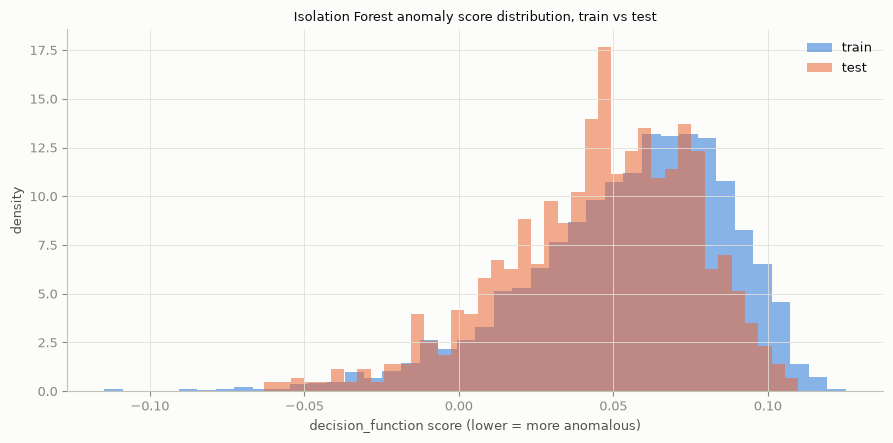

In [12]:
import matplotlib.pyplot as plt

CAT = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']
INK_PRIMARY, INK_SECONDARY, INK_MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, BASELINE_LINE, SURFACE = '#e1e0d9', '#c3c2b7', '#fcfcfb'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'axes.edgecolor': BASELINE_LINE,
    'axes.labelcolor': INK_SECONDARY, 'text.color': INK_PRIMARY, 'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED, 'grid.color': GRID, 'font.size': 9, 'axes.grid': True,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
})

train_scores = iso_model.decision_function(X_train)
test_scores = iso_model.decision_function(X_test)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(train_scores, bins=40, color=CAT[0], alpha=0.55, label='train', density=True)
ax.hist(test_scores, bins=40, color=CAT[1], alpha=0.55, label='test', density=True)
ax.set_xlabel('decision_function score (lower = more anomalous)')
ax.set_ylabel('density')
ax.set_title('Isolation Forest anomaly score distribution, train vs test', fontsize=9)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


In [13]:
pd.Series(train_scores).describe(), pd.Series(test_scores).describe()


(count    3766.000000
 mean        0.054847
 std         0.033029
 min        -0.114695
 25%         0.035642
 50%         0.059896
 75%         0.078913
 max         0.125276
 dtype: float64,
 count    994.000000
 mean       0.045487
 std        0.030995
 min       -0.063068
 25%        0.027097
 50%        0.048222
 75%        0.068756
 max        0.109886
 dtype: float64)

## Training time

In [14]:
pd.DataFrame([
    {
        'path': result['path'],
        'contamination': r['contamination'],
        'n_estimators': iso_model.n_estimators,
        'feature_set_version': m.FEATURE_SET_VERSION,
        'training_seconds': r['training_seconds'],
    }
    for r in result['runs'].values()
])


,path,contamination,n_estimators,feature_set_version,training_seconds
0,A,0.067977,200,v1,0.214072


## Evaluation path selection

In [15]:
from src import evaluate as ev

diagnostics = ev.select_evaluation_path(meta_train, df)
diagnostics

{'rate0': 0.06797663303239511,
 'base_rate': 0.9320233669676049,
 'max_single_column_edge_pp': 0.26553372278279586,
 'single_column_edges_pp': {'throughput_mbps': 0.0,
  'latency_ms': 0.0,
  'packet_loss_pct': 0.26553372278279586,
  'handover_count': 0.0,
  'rsrp_dbm': 0.026553372278281806,
  'rsrq_db': 0.0,
  'prb_utilization_pct': 0.0,
  'active_users': 0.0},
 'degenerate_rate': False,
 'trivial_single_column': False}

## Evaluation on temporal test split

In [16]:
models_by_contamination = {c: r['model'] for c, r in result['runs'].items()}
result_eval = ev.run_evaluation(df, meta_train, X_test, meta_test, models_by_contamination)
result_eval['path'], result_eval['pr_auc']

('A', 0.18081379217222388)

In [17]:
result_eval['precision_recall_at_k']


,k_pct,precision,recall,n_alerts
0,0.005,0.500000,0.055556,6
1,0.010,0.363636,0.074074,11
2,0.020,0.333333,0.129630,21
3,0.050,0.260000,0.240741,50
4,0.100,0.180000,0.333333,100
5,0.150,0.160000,0.444444,150


In [18]:
result_eval['target_recall'], result_eval['fpr_at_target_recall']


(0.9, 0.7127659574468085)

In [19]:
result_eval['capacity_severity_table']

,k_pct,alerts_per_day,precision,recall,n_false_negatives,mean_severity_missed,max_severity_missed,within_capacity
0,0.005,8.692153,0.500000,0.055556,51,1.142250,1.909952,True
1,0.010,15.935614,0.363636,0.074074,50,1.128336,1.909952,True
2,0.020,30.422535,0.333333,0.129630,47,1.086363,1.800044,True
3,0.050,72.434608,0.260000,0.240741,41,1.027202,1.425258,False
4,0.100,144.869215,0.180000,0.333333,36,0.994646,1.425258,False
5,0.150,217.303823,0.160000,0.444444,30,0.936655,1.267411,False


In [20]:
result_eval['production_k']

{'k_pct': 0.02,
 'alerts_per_day': 30.422535211267604,
 'precision': 0.3333333333333333,
 'recall': 0.12962962962962962,
 'n_false_negatives': 47,
 'mean_severity_missed': 1.0863631908528721,
 'max_severity_missed': 1.8000440478137025,
 'within_capacity': True}

## Root cause: deviation-contribution ranking

In [21]:
from src import root_cause as rc

test_scores = ev.anomaly_score(iso_model, X_test)
test_dates = meta_test["timestamp"].dt.date.to_numpy()
alerted_mask = ev._alert_mask(test_scores, test_dates, result_eval["production_k"]["k_pct"])
true_positive_mask = alerted_mask & (meta_test["sla_compliant"] == 0).to_numpy()
flagged_row_idx = X_test.index[true_positive_mask][0]
meta_test.loc[flagged_row_idx]

timestamp        2024-01-04 02:55:00
cell_id                     CELL_003
slice_type                      mMTC
cell_type                      macro
sla_compliant                      0
Name: 124, dtype: object

In [22]:
rc.rank_deviation_contributions(X_test, flagged_row_idx)

,kpi,zscore
0,packet_loss_pct,9.682889
1,throughput_mbps,2.575744
2,rsrp_dbm,-1.583005
3,handover_count,0.842927
4,latency_ms,-0.420547
